In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv("../DATA/processed/truck_processed.csv")
df.shape

(5000, 19)

In [2]:
df.head(5)

,Driver_Age,Driving_Hours,Speed,Harsh_Braking,Harsh_Acceleration,Drowsiness_Score,Engine_Temperature,Engine_Vibration,Battery_Voltage,Oil_Pressure,Tyre_Pressure,Vehicle_Age,Mileage,Previous_Breakdowns,Previous_Accidents,Weather,Road_Type,Driver_Risk,Breakdown_Risk
0,50,5.4,47,2,1,65.7,83.1,1.76,13.08,59.9,35.5,6,423852,0,0,Clear,Highway,0,0
1,36,9.3,69,1,0,100.0,97.2,3.68,11.88,38.0,37.8,13,883857,4,0,Rain,City,1,1
2,29,6.0,81,1,2,70.0,93.8,1.98,12.30,50.0,35.3,14,680286,1,0,Clear,Highway,0,0
3,42,5.5,62,1,4,62.2,84.9,4.25,12.90,32.4,36.8,4,289202,0,0,Clear,Highway,0,0
4,40,11.3,55,0,0,100.0,94.0,4.85,12.56,28.9,33.0,11,172552,1,0,Clear,Highway,1,0


In [3]:
df.columns

Index(['Driver_Age', 'Driving_Hours', 'Speed', 'Harsh_Braking',
       'Harsh_Acceleration', 'Drowsiness_Score', 'Engine_Temperature',
       'Engine_Vibration', 'Battery_Voltage', 'Oil_Pressure', 'Tyre_Pressure',
       'Vehicle_Age', 'Mileage', 'Previous_Breakdowns', 'Previous_Accidents',
       'Weather', 'Road_Type', 'Driver_Risk', 'Breakdown_Risk'],
      dtype='str')

In [4]:
X = df.drop(columns=["Breakdown_Risk", "Driver_Risk"])
y = df["Breakdown_Risk"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5000, 17)
Target shape: (5000,)


In [5]:
numerical_features = [
    "Engine_Temperature",
    "Engine_Vibration",
    "Battery_Voltage",
    "Oil_Pressure",
    "Tyre_Pressure",
    "Vehicle_Age",
    "Mileage",
    "Previous_Breakdowns"
]

categorical_features = [
    "Weather",
    "Road_Type"
]

In [6]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


In [7]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])



In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

breakdown_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

In [9]:
breakdown_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Driver_Age','Driving_Hours','Speed',...,'Previous_Accidents','Weather', 'Road_Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='

In [10]:
y_pred = breakdown_model.predict(x_test)

In [11]:
y_pred = breakdown_model.predict(x_test)

y_probability = breakdown_model.predict_proba(x_test)[:, 1]

print("Predictions generated successfully ✅")
print("First 10 Predictions:", y_pred[:10])
print("First 10 Probabilities:", y_probability[:10])

Predictions generated successfully ✅
First 10 Predictions: [0 0 0 1 0 0 0 0 0 0]
First 10 Probabilities: [0.005 0.    0.005 0.735 0.12  0.    0.11  0.    0.01  0.05 ]


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import accuracy_score
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy score:")
print("accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       928
           1       0.96      0.75      0.84        72

    accuracy                           0.98      1000
   macro avg       0.97      0.87      0.92      1000
weighted avg       0.98      0.98      0.98      1000

Confusion Matrix:
[[926   2]
 [ 18  54]]
Accuracy score:
accuracy: 0.98


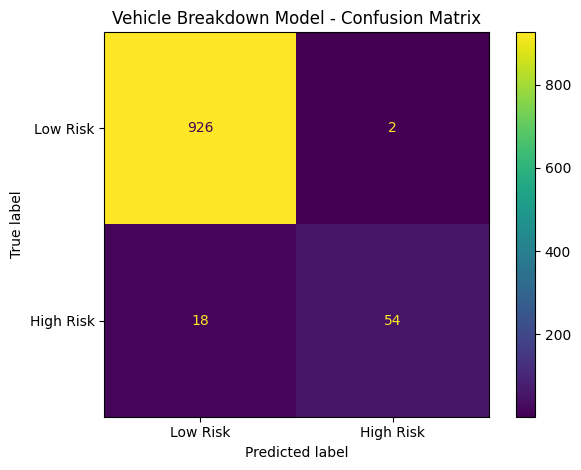

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Risk", "High Risk"]
)

disp.plot()

plt.title("Vehicle Breakdown Model - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../REPORTS/FIGURES/breakdown_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Top 10 Important Features:


,Feature,Importance
0,num__Engine_Temperature,0.356982
1,num__Engine_Vibration,0.164860
6,num__Mileage,0.120652
5,num__Vehicle_Age,0.104015
2,num__Battery_Voltage,0.075464
3,num__Oil_Pressure,0.062880
4,num__Tyre_Pressure,0.048357
7,num__Previous_Breakdowns,0.041256
12,cat__Road_Type_Highway,0.004637
9,cat__Weather_Fog,0.004549


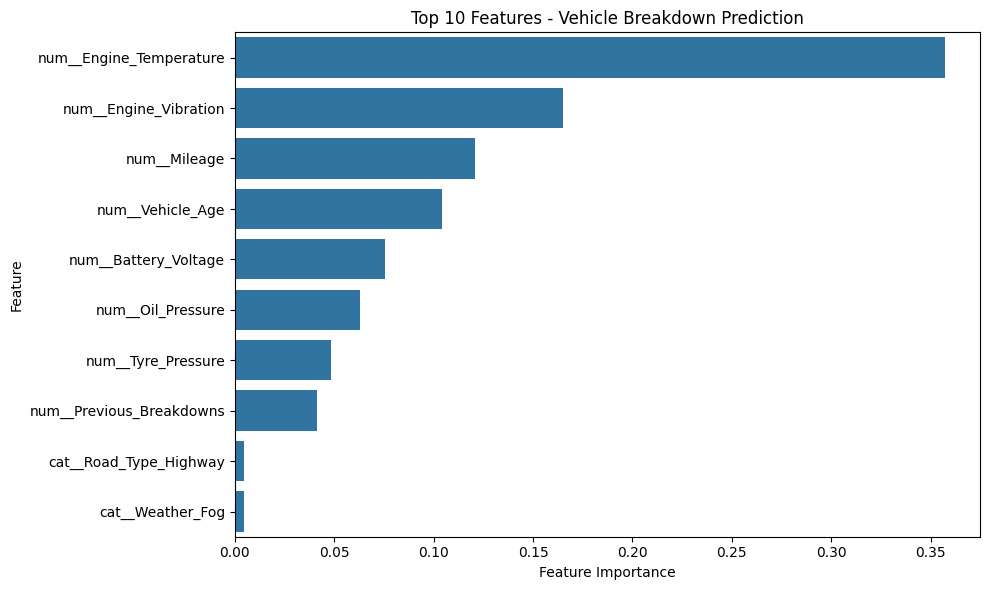

In [15]:
import seaborn as sns
feature_names = breakdown_model.named_steps["preprocessor"].get_feature_names_out()

importances = breakdown_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Important Features:")
display(feature_importance_df.head(10))
plt.figure(figsize=(10, 6))

top_features = feature_importance_df.head(10)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features - Vehicle Breakdown Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../REPORTS/FIGURES/breakdown_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
import joblib

joblib.dump(
    breakdown_model,
    "../MODELS/breakdown_model.pkl"
)

joblib.dump(
    preprocessor,
    "../MODELS/vehicle_preprocessor.pkl"
)



['../MODELS/vehicle_preprocessor.pkl']

In [19]:
import sklearn
print(sklearn.__version__)

1.9.0
